# Linear Regression With Normal-Base Transformed Mixture Priors

This notebook builds two NumPyro transformed distributions from two different Gaussian mixtures using a standard normal base, then uses them as priors for intercept and slope in a linear regression with MCMC.


In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from numpyro_extras.mixture_transform_builder import (
    MixtureTransformBuildConfig,
    build_mixture_transform,
)

jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")


/Users/holtw/Documents/mydocs/software/numpyro-extras/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Build Two Different Normal-Base Mixture Transforms

- Intercept prior target: bimodal mixture centered near `-1` and `2`.
- Slope prior target: trimodal mixture with mass near negative, near-zero, and positive slopes.


In [2]:
intercept_mixture = dist.MixtureSameFamily(
    dist.Categorical(probs=jnp.array([0.6, 0.4], dtype=jnp.float64)),
    dist.Normal(
        loc=jnp.array([-1.0, 2.0], dtype=jnp.float64),
        scale=jnp.array([0.45, 0.35], dtype=jnp.float64),
    ),
)
slope_mixture = dist.MixtureSameFamily(
    dist.Categorical(probs=jnp.array([0.25, 0.5, 0.25], dtype=jnp.float64)),
    dist.Normal(
        loc=jnp.array([-0.9, 0.2, 1.3], dtype=jnp.float64),
        scale=jnp.array([0.25, 0.2, 0.3], dtype=jnp.float64),
    ),
)
build_cfg = MixtureTransformBuildConfig(knot_cfg={"num_knots": 1025})
intercept_result = build_mixture_transform(
    base="normal",
    mixture=intercept_mixture,
    build_cfg=build_cfg,
)
slope_result = build_mixture_transform(
    base="normal",
    mixture=slope_mixture,
    build_cfg=build_cfg,
)
intercept_transform = intercept_result.transform
slope_transform = slope_result.transform
print("Intercept transform approximation diagnostics:")
print(intercept_result.diagnostics["approximation"])
print("\nSlope transform approximation diagnostics:")
print(slope_result.diagnostics["approximation"])


Intercept transform approximation diagnostics:
{'finite_forward': True, 'finite_inverse': True, 'roundtrip_max_abs_error': 9.115840526874308e-09, 'roundtrip_mean_abs_error': 6.91625942086599e-11, 'roundtrip_interior_max_abs_error': 2.2319923687064147e-12, 'monotone_forward': True, 'mixture_cdf_grid_min': 1.647807760248802e-08, 'mixture_cdf_grid_max': 0.9999999836839891}

Slope transform approximation diagnostics:
{'finite_forward': True, 'finite_inverse': True, 'roundtrip_max_abs_error': 9.115840526874308e-09, 'roundtrip_mean_abs_error': 6.916248426950185e-11, 'roundtrip_interior_max_abs_error': 2.2319923687064147e-12, 'monotone_forward': True, 'mixture_cdf_grid_min': 1.6114135603830126e-08, 'mixture_cdf_grid_max': 0.9999999838841918}


## Generate Synthetic Linear Data


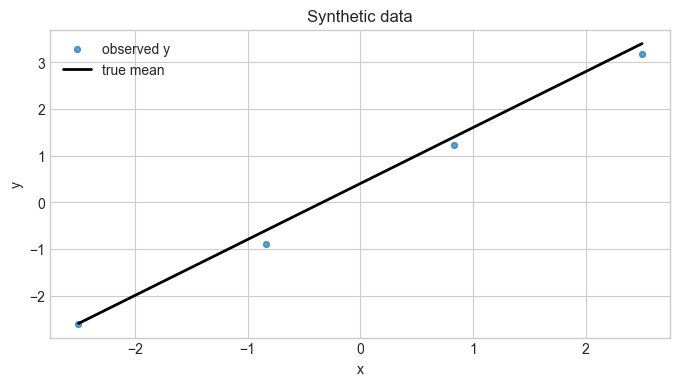

In [20]:
key = jax.random.PRNGKey(2026)
key_x, key_noise = jax.random.split(key)

n = 4
x = jnp.linspace(-2.5, 2.5, n)
true_intercept = 0.4
true_slope = 1.2
true_sigma = 0.25

y_mean = true_intercept + true_slope * x
y = y_mean + true_sigma * jax.random.normal(key_noise, shape=x.shape)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(np.asarray(x), np.asarray(y), alpha=0.7, s=18, label="observed y")
ax.plot(np.asarray(x), np.asarray(y_mean), color="black", lw=2, label="true mean")
ax.set_title("Synthetic data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
plt.show()


## Model: Use Transformed Priors For Intercept And Slope


In [21]:
base_standard_normal = dist.Normal(jnp.array(0.0), jnp.array(1.0))

intercept_prior = dist.TransformedDistribution(base_standard_normal, intercept_transform)
slope_prior = dist.TransformedDistribution(base_standard_normal, slope_transform)

def linear_model(x_obs, y_obs=None):
    intercept = numpyro.sample("intercept", intercept_prior)
    slope = numpyro.sample("slope", slope_prior)
    sigma = numpyro.sample("sigma", dist.HalfNormal(jnp.array(1.0)))

    mean = intercept + slope * x_obs
    numpyro.sample("y", dist.Normal(mean, sigma), obs=y_obs)


## Prior Visualizations And Prior Predictive Check

Before posterior inference, inspect the implied priors for the model parameters and the prior predictive distribution for `y` across `x`.


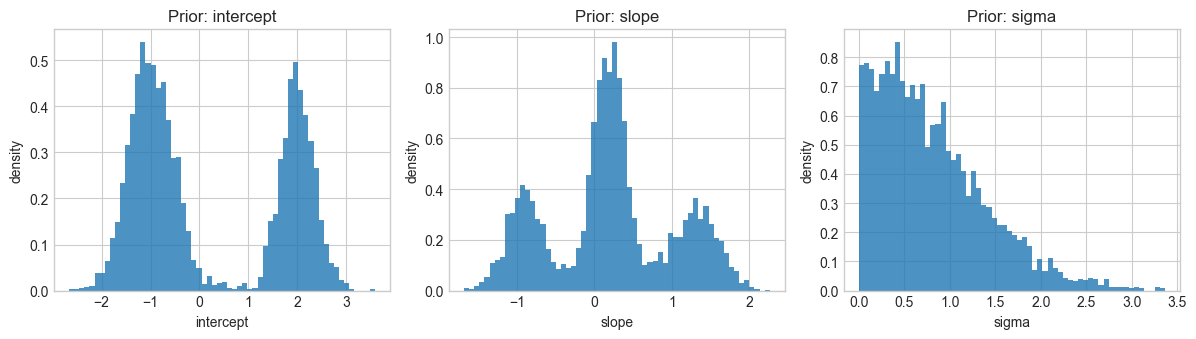

In [22]:
key_prior = jax.random.PRNGKey(777)
key_intercept, key_slope, key_sigma = jax.random.split(key_prior, 3)
n_prior_draws = 4000

prior_samples = {
    "intercept": intercept_prior.sample(key_intercept, sample_shape=(n_prior_draws,)),
    "slope": slope_prior.sample(key_slope, sample_shape=(n_prior_draws,)),
    "sigma": dist.HalfNormal(jnp.array(1.0)).sample(key_sigma, sample_shape=(n_prior_draws,)),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, name in zip(axes, ["intercept", "slope", "sigma"]):
    vals = np.asarray(prior_samples[name])
    ax.hist(vals, bins=60, density=True, alpha=0.8)
    ax.set_title(f"Prior: {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()


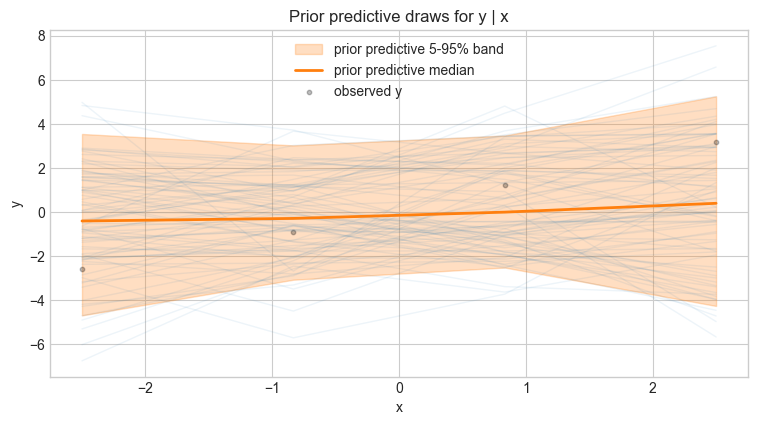

In [23]:
key_pp = jax.random.PRNGKey(888)
key_pp_intercept, key_pp_slope, key_pp_sigma, key_pp_noise = jax.random.split(key_pp, 4)
n_prior_predictive = 300

intercept_pp = intercept_prior.sample(key_pp_intercept, sample_shape=(n_prior_predictive,))
slope_pp = slope_prior.sample(key_pp_slope, sample_shape=(n_prior_predictive,))
sigma_pp = dist.HalfNormal(jnp.array(1.0)).sample(key_pp_sigma, sample_shape=(n_prior_predictive,))

mean_pp = intercept_pp[:, None] + slope_pp[:, None] * x[None, :]
noise_pp = sigma_pp[:, None] * jax.random.normal(key_pp_noise, shape=mean_pp.shape)
y_pp = mean_pp + noise_pp

y_pp_q05, y_pp_q50, y_pp_q95 = jnp.quantile(y_pp, jnp.array([0.05, 0.5, 0.95]), axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i in range(min(80, n_prior_predictive)):
    ax.plot(np.asarray(x), np.asarray(y_pp[i]), color="tab:blue", alpha=0.08, lw=1.0)

ax.fill_between(
    np.asarray(x),
    np.asarray(y_pp_q05),
    np.asarray(y_pp_q95),
    color="tab:orange",
    alpha=0.25,
    label="prior predictive 5-95% band",
)
ax.plot(np.asarray(x), np.asarray(y_pp_q50), color="tab:orange", lw=2, label="prior predictive median")
ax.scatter(np.asarray(x), np.asarray(y), color="black", s=10, alpha=0.25, label="observed y")

ax.set_title("Prior predictive draws for y | x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
plt.show()


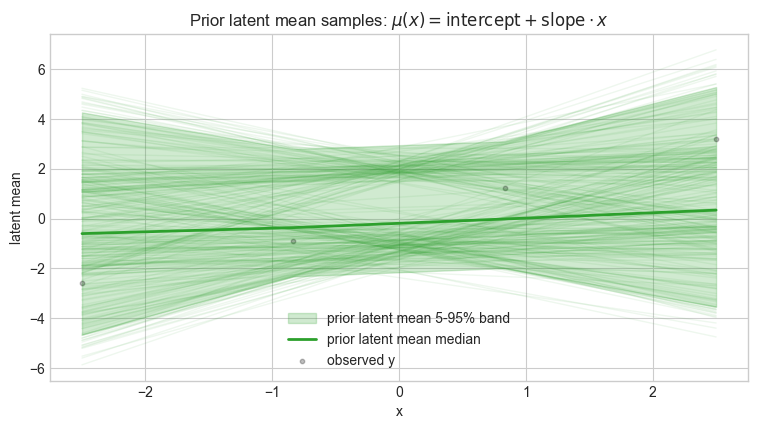

In [24]:
x_np = np.asarray(x)
y_np = np.asarray(y)

prior_latent_mean = (
    np.asarray(prior_samples["intercept"])[:, None]
    + np.asarray(prior_samples["slope"])[:, None] * x_np[None, :]
)
mu_prior_q05, mu_prior_q50, mu_prior_q95 = np.quantile(prior_latent_mean, [0.05, 0.5, 0.95], axis=0)

rng_prior_latent = np.random.default_rng(999)
n_prior_latent = min(300, prior_latent_mean.shape[0])
prior_latent_ids = rng_prior_latent.choice(prior_latent_mean.shape[0], size=n_prior_latent, replace=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
for idx in prior_latent_ids:
    ax.plot(x_np, prior_latent_mean[idx], color="tab:green", alpha=0.08, lw=1)
ax.fill_between(x_np, mu_prior_q05, mu_prior_q95, color="tab:green", alpha=0.22, label="prior latent mean 5-95% band")
ax.plot(x_np, mu_prior_q50, color="tab:green", lw=2, label="prior latent mean median")
ax.scatter(x_np, y_np, color="black", s=10, alpha=0.25, label="observed y")
ax.set_title("Prior latent mean samples: $\\mu(x)=\\mathrm{intercept}+\\mathrm{slope}\\cdot x$")
ax.set_xlabel("x")
ax.set_ylabel("latent mean")
ax.legend(loc="best")
plt.show()


## Run NUTS / MCMC And Summarize Posterior


In [29]:
numpyro.set_host_device_count(1)

nuts = NUTS(linear_model)
mcmc = MCMC(
    nuts,
    num_warmup=1000,
    num_samples=2000,
    num_chains=4,
    progress_bar=False,
)

key_mcmc = jax.random.PRNGKey(314)
mcmc.run(key_mcmc, x_obs=x, y_obs=y)
mcmc.print_summary(exclude_deterministic=False)

posterior = mcmc.get_samples()
for name, arr in posterior.items():
    print(f"{name}: mean={arr.mean():.3f}, std={arr.std():.3f}")


/var/folders/qd/nzzrspw15ks3cp9_3_d2k3z00000gp/T/ipykernel_17896/4189400436.py:4: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  intercept      0.00      0.48      0.11     -0.81      0.50    309.36      1.01
      sigma      0.55      0.48      0.38      0.06      1.25    389.55      1.01
      slope      1.16      0.20      1.18      0.96      1.48    489.53      1.01

Number of divergences: 28
intercept: mean=0.005, std=0.478
sigma: mean=0.555, std=0.484
slope: mean=1.161, std=0.203


## Posterior Predictive Check


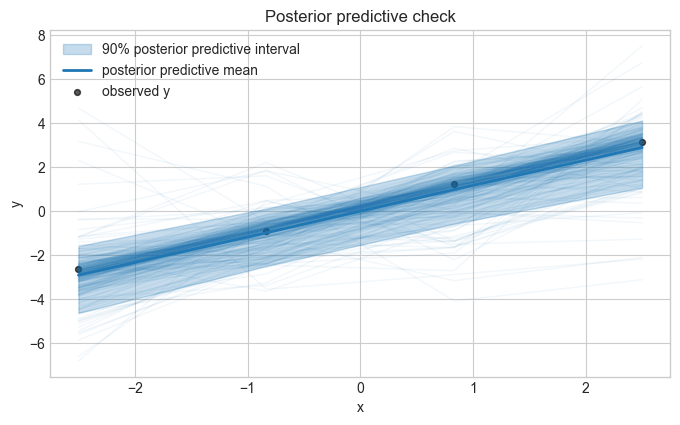

In [31]:
predictive = Predictive(linear_model, posterior_samples=posterior, return_sites=["y"])
key_post_pred = jax.random.PRNGKey(2718)
y_post_pred = np.asarray(predictive(key_post_pred, x_obs=x)["y"])

y_pred_mean = y_post_pred.mean(axis=0)
y_pred_lo, y_pred_hi = np.quantile(y_post_pred, [0.05, 0.95], axis=0)

rng = np.random.default_rng(2718)
num_lines = min(300, y_post_pred.shape[0])
draw_ids = rng.choice(y_post_pred.shape[0], size=num_lines, replace=False)

x_np = np.asarray(x)
y_np = np.asarray(y)

fig, ax = plt.subplots(figsize=(8, 4.5))
for idx in draw_ids:
    ax.plot(x_np, y_post_pred[idx], color="tab:blue", alpha=0.06, lw=1)
ax.fill_between(x_np, y_pred_lo, y_pred_hi, color="tab:blue", alpha=0.25, label="90% posterior predictive interval")
ax.plot(x_np, y_pred_mean, color="tab:blue", lw=2, label="posterior predictive mean")
ax.scatter(x_np, y_np, s=18, color="black", alpha=0.65, label="observed y")
ax.set_title("Posterior predictive check")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best")
plt.show()


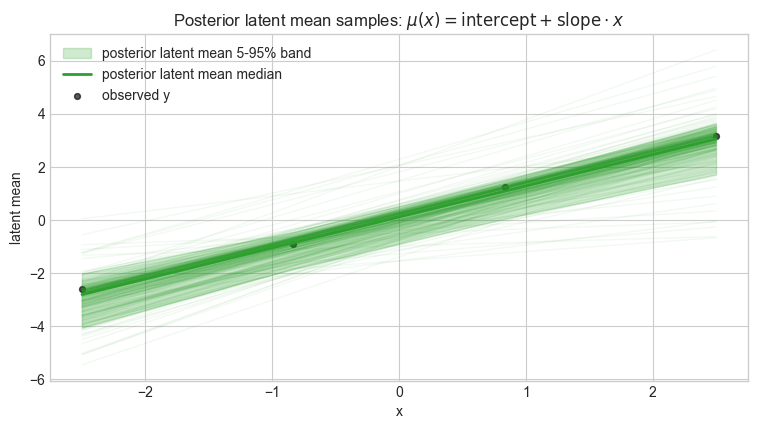

In [33]:
x_np = np.asarray(x)
y_np = np.asarray(y)

posterior_latent_mean = (
    np.asarray(posterior["intercept"])[:, None]
    + np.asarray(posterior["slope"])[:, None] * x_np[None, :]
)
mu_post_q05, mu_post_q50, mu_post_q95 = np.quantile(posterior_latent_mean, [0.05, 0.5, 0.95], axis=0)

rng_post_latent = np.random.default_rng(1234)
n_post_latent = min(300, posterior_latent_mean.shape[0])
post_latent_ids = rng_post_latent.choice(posterior_latent_mean.shape[0], size=n_post_latent, replace=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
for idx in post_latent_ids:
    ax.plot(x_np, posterior_latent_mean[idx], color="tab:green", alpha=0.06, lw=1)
ax.fill_between(x_np, mu_post_q05, mu_post_q95, color="tab:green", alpha=0.22, label="posterior latent mean 5-95% band")
ax.plot(x_np, mu_post_q50, color="tab:green", lw=2, label="posterior latent mean median")
ax.scatter(x_np, y_np, s=18, color="black", alpha=0.65, label="observed y")
ax.set_title("Posterior latent mean samples: $\\mu(x)=\\mathrm{intercept}+\\mathrm{slope}\\cdot x$")
ax.set_xlabel("x")
ax.set_ylabel("latent mean")
ax.legend(loc="best")
plt.show()


## Simple Posterior Plots


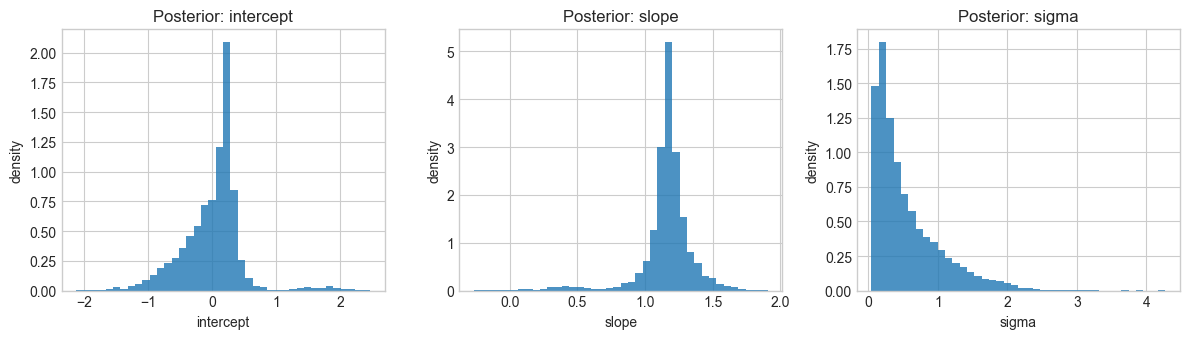

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, name in zip(axes, ["intercept", "slope", "sigma"]):
    vals = np.asarray(posterior[name])
    ax.hist(vals, bins=40, density=True, alpha=0.8)
    ax.set_title(f"Posterior: {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("density")
plt.tight_layout()
plt.show()
